# Tyre Degradation Analysis — Verstappen vs Alonso 
# Bahrain 2023 Race

## Context
This notebook analyses tyre degradation during a race using 
available FastF1 data. The model incorporates key parameters: 
TyreLife, fuel weight correction, and stint separation.

**Race strategies compared:**
- **Verstappen (Red Bull):** Soft → Soft → Hard
- **Alonso (Aston Martin):** Soft → Hard → Hard

This analysis aims to understand how tyre management and 
race strategy directly influence race performance 
(Segers, Chapter 16.2).



In [100]:
import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

session = fastf1.get_session(2023, 'Bahrain', 'R')
session.load()

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


In [101]:
laps_VER = session.laps.pick_drivers('VER')
laps_ALO = session.laps.pick_drivers('ALO')

for stint in laps_VER['Stint'].unique():
    print(f"Stint {stint}:")
    stint_laps = laps_VER[laps_VER['Stint'] == stint]
    print(stint_laps[['LapNumber', 'Compound', 'TyreLife']])





Stint 1.0:
    LapNumber Compound  TyreLife
0         1.0     SOFT       4.0
1         2.0     SOFT       5.0
2         3.0     SOFT       6.0
3         4.0     SOFT       7.0
4         5.0     SOFT       8.0
5         6.0     SOFT       9.0
6         7.0     SOFT      10.0
7         8.0     SOFT      11.0
8         9.0     SOFT      12.0
9        10.0     SOFT      13.0
10       11.0     SOFT      14.0
11       12.0     SOFT      15.0
12       13.0     SOFT      16.0
13       14.0     SOFT      17.0
Stint 2.0:
    LapNumber Compound  TyreLife
14       15.0     SOFT       1.0
15       16.0     SOFT       2.0
16       17.0     SOFT       3.0
17       18.0     SOFT       4.0
18       19.0     SOFT       5.0
19       20.0     SOFT       6.0
20       21.0     SOFT       7.0
21       22.0     SOFT       8.0
22       23.0     SOFT       9.0
23       24.0     SOFT      10.0
24       25.0     SOFT      11.0
25       26.0     SOFT      12.0
26       27.0     SOFT      13.0
27       28.0     SOF

## Lap Time vs Tyre Life Analysis

### Methodology
To approximate real tyre degradation, we compare corrected 
lap times against tyre age (TyreLife).

**Data filtering — ±3% median filter:**
Lap times deviating more than 3% from the session median 
are excluded. These outliers typically correspond to Safety 
Car laps, tyre warm-up laps, or pit in/out laps.

**Fuel weight correction:**
Fuel load directly impacts lap time. Each lap, an F1 car 
consumes approximately 2.3 kg of fuel. As established by 
Segers (p.438), every kilogram of fuel improves lap time 
by ~0.03s. We therefore apply the following correction:

`Corrected Time = Raw Lap Time + 0.069s × (LapNumber - 1)`

This normalises all lap times to the equivalent of a 
full fuel load, isolating the tyre degradation effect.

VER Stint 1 (SOFT) : +0.089 s/lap
VER Stint 2 (SOFT) : +0.070 s/lap
VER Stint 3 (HARD) : +0.082 s/lap
ALO Stint 1 (SOFT) : +0.185 s/lap
ALO Stint 2 (HARD) : +0.105 s/lap
ALO Stint 3 (HARD) : +0.091 s/lap


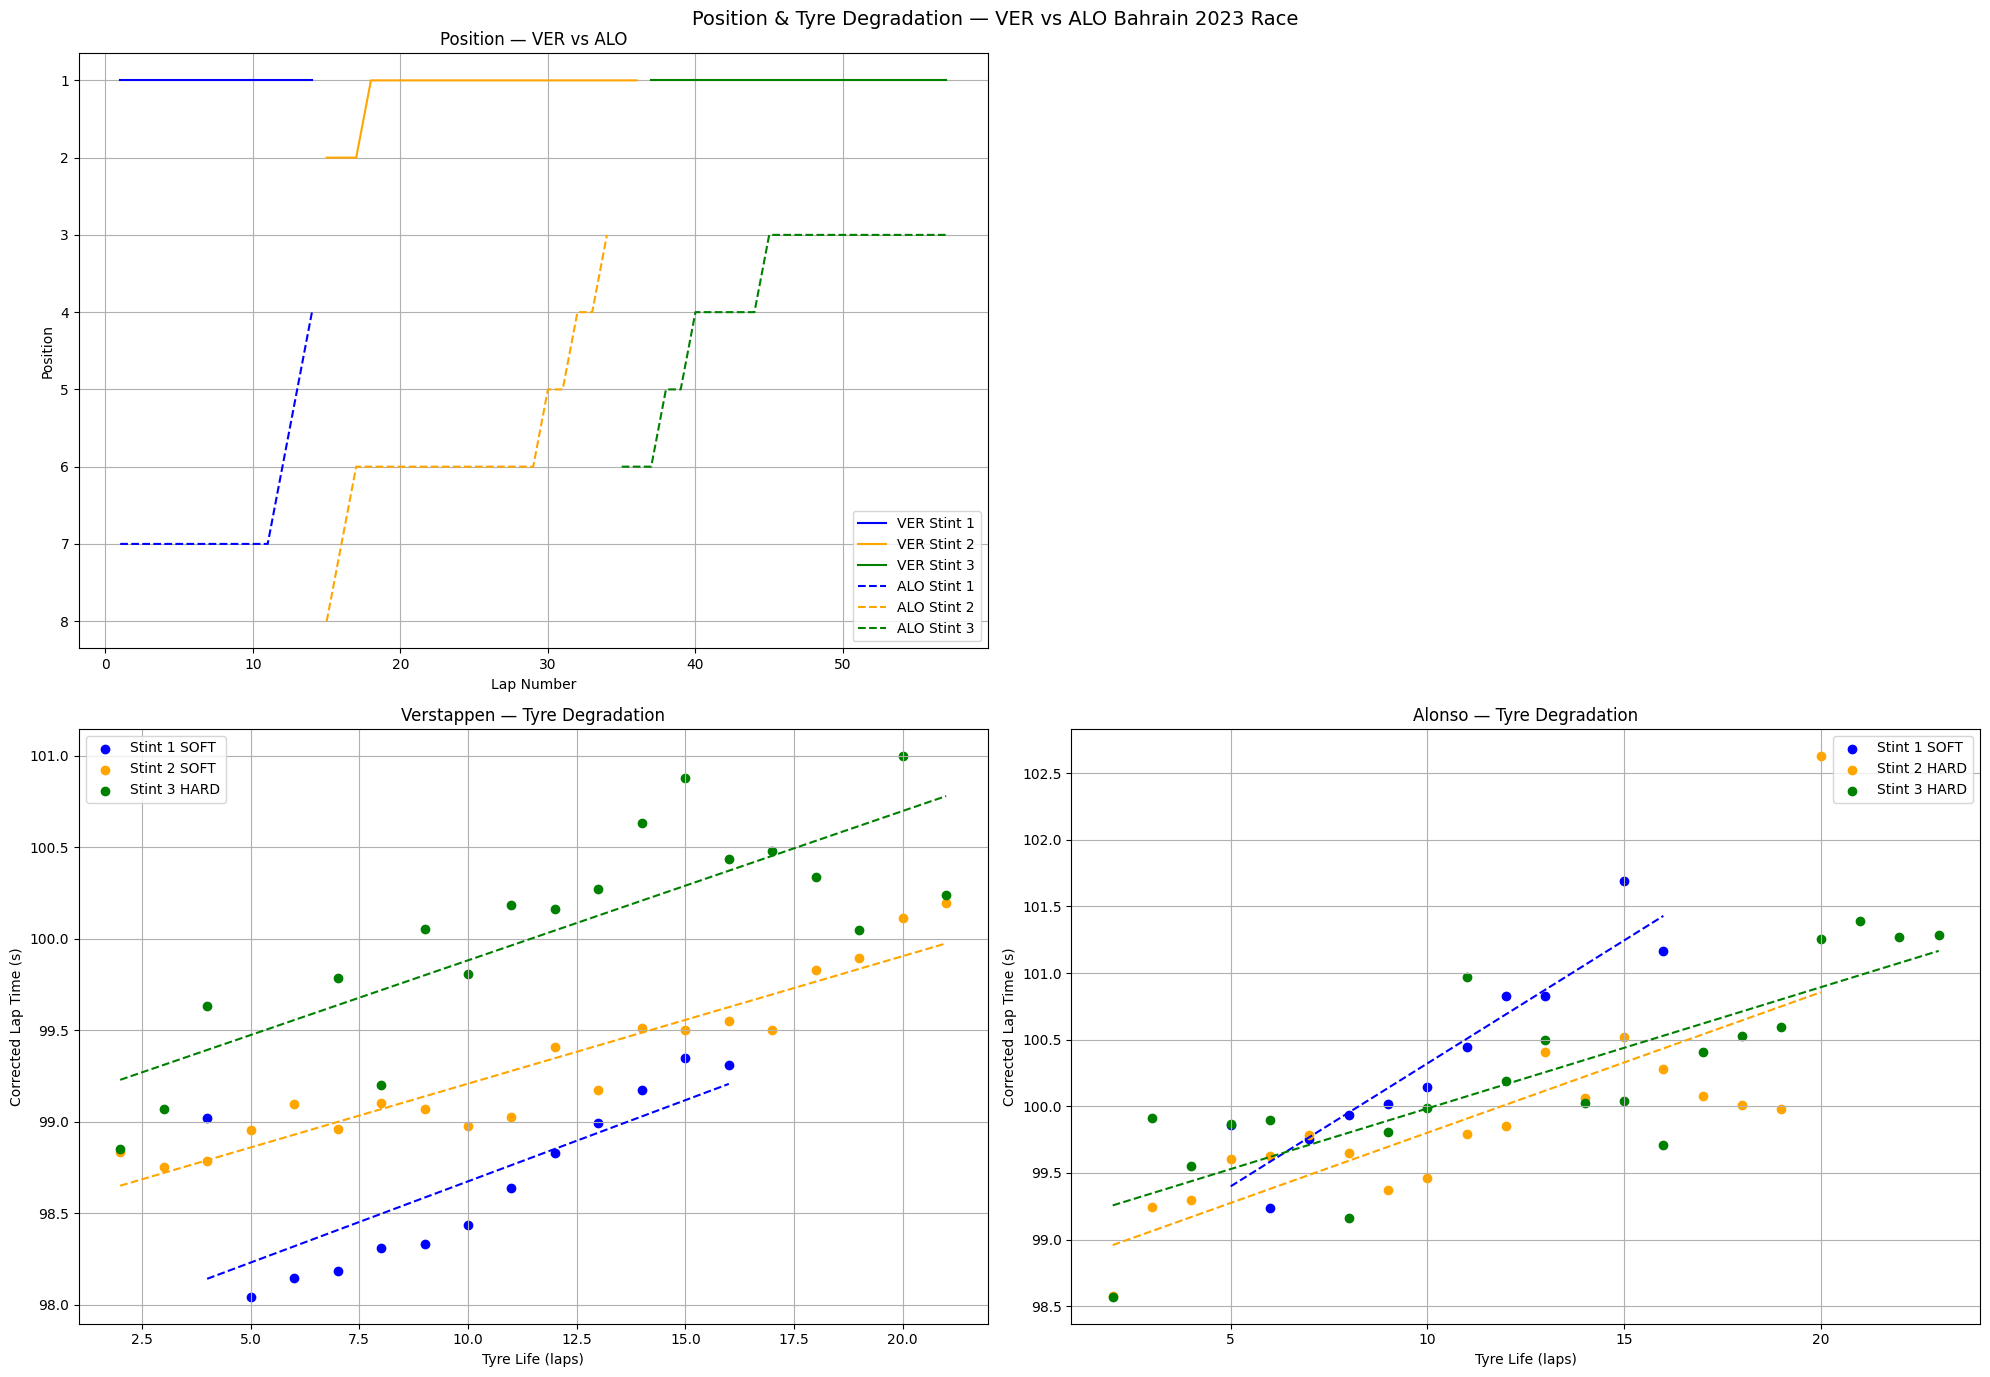

In [102]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── Filtrage & correction carburant ──────────────────────
lap_times_VER = laps_VER['LapTime'].dt.total_seconds()
median_VER = lap_times_VER.median()
laps_VER_clean = laps_VER[
    (lap_times_VER < median_VER * 1.03) &
    (lap_times_VER > median_VER * 0.97)
].copy()

lap_times_ALO = laps_ALO['LapTime'].dt.total_seconds()
median_ALO = lap_times_ALO.median()
laps_ALO_clean = laps_ALO[
    (lap_times_ALO < median_ALO * 1.03) &
    (lap_times_ALO > median_ALO * 0.97)
].copy()

FUEL_EFFECT_PER_LAP = 2.3 * 0.03
laps_VER_clean['LapTime_corrected'] = (
    laps_VER_clean['LapTime'].dt.total_seconds() +
    FUEL_EFFECT_PER_LAP * (laps_VER_clean['LapNumber'] - 1)
)
laps_ALO_clean['LapTime_corrected'] = (
    laps_ALO_clean['LapTime'].dt.total_seconds() +
    FUEL_EFFECT_PER_LAP * (laps_ALO_clean['LapNumber'] - 1)
)

# ── Conversion Position en entier ───────────────────────
laps_VER_clean['Position'] = laps_VER_clean['Position'].astype(int)
laps_ALO_clean['Position'] = laps_ALO_clean['Position'].astype(int)

# ── Couleurs par stint ───────────────────────────────────
stint_colors = {1: 'blue', 2: 'orange', 3: 'green'}

# ── [0,0] Position — données NON filtrées ───────────────
for stint in laps_VER['Stint'].unique():
    d = laps_VER[laps_VER['Stint'] == stint].copy()
    d['Position'] = d['Position'].astype(int)
    axes[0,0].plot(d['LapNumber'], d['Position'],
                   color=stint_colors[int(stint)],
                   label=f'VER Stint {int(stint)}')

for stint in laps_ALO['Stint'].unique():
    d = laps_ALO[laps_ALO['Stint'] == stint].copy()
    d['Position'] = d['Position'].astype(int)
    axes[0,0].plot(d['LapNumber'], d['Position'],
                   color=stint_colors[int(stint)],
                   linestyle='--',
                   label=f'ALO Stint {int(stint)}')

axes[0,0].invert_yaxis()
axes[0,0].set_title('Position — VER vs ALO')
axes[0,0].set_xlabel('Lap Number')
axes[0,0].set_ylabel('Position')
axes[0,0].legend()
axes[0,0].grid()

# ── [0,1] Vide ───────────────────────────────────────────
axes[0,1].axis('off')

# ── [1,0] Dégradation VER ────────────────────────────────
for stint in laps_VER_clean['Stint'].unique():
    d = laps_VER_clean[laps_VER_clean['Stint'] == stint]
    x = d['TyreLife'].values
    y = d['LapTime_corrected'].values
    coeffs = np.polyfit(x, y, 1)
    trend = np.poly1d(coeffs)
    deg_rate = coeffs[0]
    compound = d['Compound'].iloc[0]
    axes[1,0].scatter(x, y, color=stint_colors[int(stint)],
                      label=f'Stint {int(stint)} {compound}')
    axes[1,0].plot(x, trend(x), linestyle='--',
                   color=stint_colors[int(stint)])
    print(f'VER Stint {int(stint)} ({compound}) : {deg_rate:+.3f} s/lap')

axes[1,0].set_title('Verstappen — Tyre Degradation')
axes[1,0].set_xlabel('Tyre Life (laps)')
axes[1,0].set_ylabel('Corrected Lap Time (s)')
axes[1,0].legend()
axes[1,0].grid()

# ── [1,1] Dégradation ALO ────────────────────────────────
for stint in laps_ALO_clean['Stint'].unique():
    d = laps_ALO_clean[laps_ALO_clean['Stint'] == stint]
    x = d['TyreLife'].values
    y = d['LapTime_corrected'].values
    coeffs = np.polyfit(x, y, 1)
    trend = np.poly1d(coeffs)
    deg_rate = coeffs[0]
    compound = d['Compound'].iloc[0]
    axes[1,1].scatter(x, y, color=stint_colors[int(stint)],
                      label=f'Stint {int(stint)} {compound}')
    axes[1,1].plot(x, trend(x), linestyle='--',
                   color=stint_colors[int(stint)])
    print(f'ALO Stint {int(stint)} ({compound}) : {deg_rate:+.3f} s/lap')

axes[1,1].set_title('Alonso — Tyre Degradation')
axes[1,1].set_xlabel('Tyre Life (laps)')
axes[1,1].set_ylabel('Corrected Lap Time (s)')
axes[1,1].legend()
axes[1,1].grid()

plt.suptitle('Position & Tyre Degradation — VER vs ALO Bahrain 2023 Race',
             fontsize=14)
plt.tight_layout()
plt.show()

### Results

**Tyre Degradation Rate:**

| Stint | Compound | VER (s/lap) | ALO (s/lap) |
|-------|----------|-------------|-------------|
| 1 | SOFT | +0.089 | +0.185 |
| 2 | SOFT/HARD | +0.070 | +0.105 |
| 3 | HARD | +0.082 | +0.091 |

### Interpretation
The results clearly confirm both strategies.

Verstappen adopted a Soft-Soft-Hard strategy, managing 
his first Soft set carefully to extend its life. His 
degradation rate on the first Soft (+0.089 s/lap) is 
**2x lower** than Alonso's (+0.185 s/lap), enabling 
Red Bull to use a second Soft set — an unusual and 
aggressive strategy choice.

Remarkably, VER's second Soft stint degrades even less 
(+0.070 s/lap) than the first, confirming exceptional 
tyre management throughout the race.

VER's Hard stint shows slightly higher degradation 
(+0.082 s/lap) — consistent with a driver pushing harder 
once the race outcome was secured.

As Segers states (p.441): *"A driver can be faster than 
the competition in a qualifying lap, but over a race 
distance a driver might have a greater degradation in 
lap times."* — This perfectly describes Alonso's situation 
in Bahrain 2023.

## Strategic Analysis — Pit Stop Timing

At lap 14, VER (P1) pitted 27 seconds before ALO (P4).
This was an offensive strategic move by Red Bull —
not a defensive reaction. By pitting first, Red Bull:

- Secured VER's track position with fresh tyres
- Forced Aston Martin to respond immediately
- Prevented any undercut attempt from ALO

Had ALO stayed out, VER would have built a gap on 
fresh Soft tyres, making any future undercut impossible.
This proactive strategy is a hallmark of Red Bull's 
dominance in 2023 — controlling races from the pit wall
rather than reacting to competitors.

### Limitations
- Fuel consumption estimated at 2.3 kg/lap — actual consumption varies by lap and driving style
- No Pirelli tyre pressure or temperature data available in FastF1 — real degradation analysis would require direct sensor data (Segers, p.85)
- The ±3% filter may occasionally exclude legitimate fast or slow laps

## Driver Consistency — Rolling Standard Deviation

### Methodology
This method analyses the driver's capacity to maintain 
consistent lap times throughout a stint. Consistency is 
a key performance factor — as Segers states (p.441): 
"A driver can be faster in qualifying but show greater 
degradation over race distance."

We apply a rolling standard deviation over 3 consecutive 
laps using the previously filtered clean lap data. This 
window of 3 laps minimises noise while remaining 
sensitive enough to detect real inconsistency.

An alert threshold is set at **0.2s**. In GT racing, 
this threshold is typically 0.6-0.8s due to lower driver 
precision. In F1, drivers are exceptionally consistent, 
so a tighter threshold is required to detect meaningful 
variations.

### Results


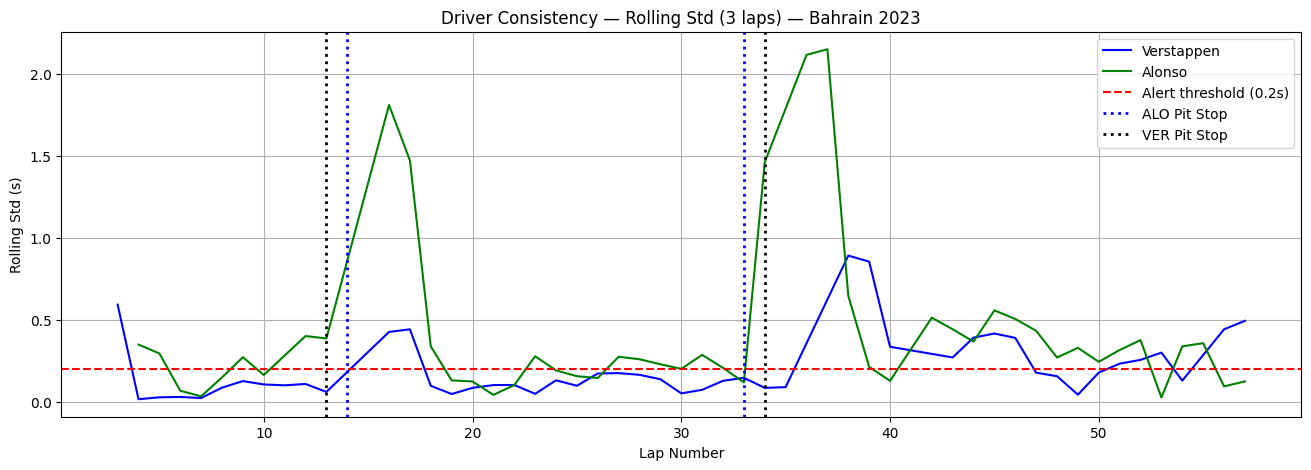

In [103]:
# Étape 1 — Extrait les lap times en secondes
lap_times_VER = laps_VER_clean['LapTime'].dt.total_seconds()
lap_times_ALO = laps_ALO_clean['LapTime'].dt.total_seconds()

# Étape 2 — Calcule le rolling std sur 3 tours
rolling_std_VER = lap_times_VER.rolling(window=3).std()
rolling_std_ALO = lap_times_ALO.rolling(window=3).std()

plt.figure(figsize=(16, 5))

plt.plot(laps_VER_clean['LapNumber'], rolling_std_VER, color='blue', label='Verstappen')
plt.plot(laps_ALO_clean['LapNumber'], rolling_std_ALO, color='green', label='Alonso')

plt.axhline(y=0.2, color='red', linestyle='--', label='Alert threshold (0.2s)')
plt.axvline(x=14, color='blue', linestyle=':', linewidth=2, label='ALO Pit Stop')
plt.axvline(x=33, color='blue', linestyle=':', linewidth=2)
plt.axvline(x=13, color='black', linestyle=':', linewidth=2, label='VER Pit Stop')
plt.axvline(x=34, color='black', linestyle=':', linewidth=2)
plt.title('Driver Consistency — Rolling Std (3 laps) — Bahrain 2023')
plt.xlabel('Lap Number')
plt.ylabel('Rolling Std (s)')
plt.legend()
plt.grid()
plt.show()







### Interpretation
The first pit stop decision for Alonso is directly 
confirmed by our method. From lap 11, ALO exceeds the 
0.2s threshold for 3 consecutive laps, indicating he is 
struggling with the car — likely due to tyre performance 
drop. Aston Martin responds by pitting ALO at lap 14.

Furthermore, during ALO's 2nd stint between laps 23-33, 
he repeatedly reaches or exceeds the threshold, suggesting 
ongoing difficulty managing the Hard tyres.

Verstappen remains more consistently below the threshold 
throughout his stint — confirming his superior tyre 
management observed in the degradation analysis.

### Decision Framework

| Degradation | Rolling Std | Problem | Action |
|-------------|-------------|---------|--------|
|  OK |  High | Driver | Radio coaching — adjust driving style |
|  High | High | Driver + Tyre | Pit stop required immediately |
|  High |  Low | Tyre only | Prepare pit stop for next lap |
|  OK | Low | No issue | Continue — monitor only |

### Limitations
- **End of race noise:** Both drivers exceed the threshold in the final laps, likely due to traffic and battles on track rather than genuine inconsistency.
- **Pit stop artefacts:** Rolling Std spikes after every pit stop as drivers warm up fresh tyres, these peaks should be excluded from the decision framework analysis.
- **Window size:** A 3-lap window may be too short to distinguish real inconsistency from isolated slow laps.